<a href="https://colab.research.google.com/github/DastanJin/ZSU/blob/main/fml_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamentals of Machine Learning - Exercise 8
Goal of the excercise is to learn how to use Scikit-learn library for a classification tasks and evaluate the performance of the proposed models.

![meme04](https://github.com/rasvob/VSB-FEI-Fundamentals-of-Machine-Learning-Exercises/blob/master/images/fml_08_meme_04.jpg?raw=true)

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, auc
from sklearn.preprocessing import OrdinalEncoder

## Data Dictionary

|Variable|Definition|Key|
|:-------|:-------|:--------|
|survival|Survival|0 = No, 1 = Yes|
|pclass|Ticket class|1 = 1st, 2 = 2nd, 3 = 3rd|
|sex|Sex||
|Age|Age in years||
|sibsp|# of siblings / spouses aboard the Titanic||
|parch|# of parents / children aboard the Titanic||
|ticket|Ticket number||
|fare|Passenger fare||
|cabin|Cabin number||
|embarked|Port of Embarkation|C = Cherbourg, Q = Queenstown, S = Southampton|

**pclass**: A proxy for socio-economic status (SES)
1st = Upper
2nd = Middle
3rd = Lower

**age**: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

**sibsp**: The dataset defines family relations in this way...
Sibling = brother, sister, stepbrother, stepsister
Spouse = husband, wife (mistresses and fiancés were ignored)

**parch**: The dataset defines family relations in this way...
Parent = mother, father
Child = daughter, son, stepdaughter, stepson
Some children travelled only with a nanny, therefore parch=0 for them.

## Useful links
* Decision tree https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
* Train test split https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
* Accuracy https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
* Metrics https://scikit-learn.org/stable/modules/model_evaluation.html
* K-Fold CV https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html#sklearn.model_selection.KFold
* Random forest https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

# 🎯 What is our goal for this dataset?
* 🔎 What are the input features?
* 🔎 What is the output?
* 🔎 What should the model do?

## Load the titanic.csv dataset first

In [39]:
df = pd.read_csv('https://raw.githubusercontent.com/rasvob/VSB-FEI-Fundamentals-of-Machine-Learning-Exercises/master/datasets/titanic.csv', index_col=0)
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


# 📊 Each task starts with basic exploration of the data

## How many passangers survived?
* Are the labels balanced?

In [40]:
df.Survived.value_counts()

,count
Survived,
0,549
1,342


# 💡 We need to pre-process the data first before training any ML model
* We want to use only numerical attributes as a model features
* Certain attributes need to be dropped and some of them can be encoded

![meme01](https://github.com/rasvob/VSB-FEI-Fundamentals-of-Machine-Learning-Exercises/blob/master/images/fml_08_meme_01.jpg?raw=true)

## Which features could be encoded and which methods would you use?

In [41]:
df.describe(exclude=np.number)

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [42]:
df.describe(include=np.number)

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## How many values are missing in the individual attributes?

In [43]:
df.isna().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0
Fare,0


# 🔎 Which features would you drop and why?

## Let's drop Name and Ticket features - these have no use for us now

In [44]:
df = df.drop(['Name', 'Ticket'], axis=1)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
PassengerId,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,NaN,S
2,1,1,female,38.0,1,0,71.2833,C85,C
3,1,3,female,26.0,0,0,7.9250,NaN,S
4,1,1,female,35.0,1,0,53.1000,C123,S
5,0,3,male,35.0,0,0,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...
887,0,2,male,27.0,0,0,13.0000,NaN,S
888,1,1,female,19.0,0,0,30.0000,B42,S
889,0,3,female,NaN,1,2,23.4500,NaN,S


# 🚤 Extract the deck identifier from the Cabin feature
* 💡 A = top deck, G = lowest deck
  
1) Change type to string
   
2) Filter the first letter using *apply* function
   
3) If the value is *nan* use *U* value as an replacement - this will mark the passangers with missing Cabin value
   
4) Replace the T value with A

In [55]:
df.loc[:, 'Cabin'] = df['Cabin'].astype(str).str[0]
df.loc[:, 'Cabin'] = df['Cabin'].replace('T', 'A')
df.loc[:, 'Cabin'] = df['Cabin'].replace('n', 'U')

In [73]:
df.Cabin.value_counts()

,count
Cabin,
7.0,529
2.0,51
1.0,43
3.0,31
4.0,30
0.0,13
5.0,11
6.0,4


# ⚠ The Age feature is tricky, we have multiple solutions for dealing with missing values, e.g.:

1) Drop the feature

2) Take the mean/median value to replace the missing value

3) Take a random list of ages that maintains the original statistical summary values

4) Use a model to predict values based on the existing values

## We will use the second option ✌

## Check the boxplot *before* and *after* the replacement
* 🔎 Is there any change?

Text(0.5, 1.0, 'Before')

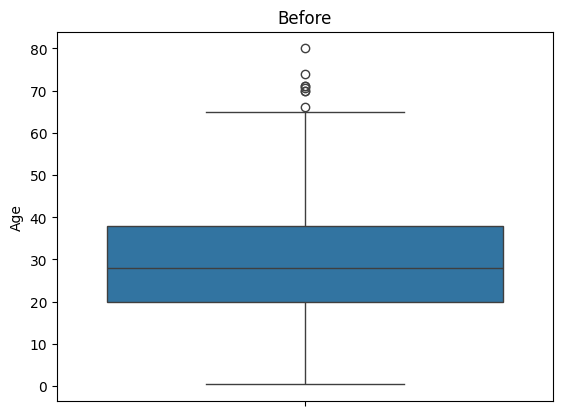

In [57]:
sns.boxplot(y=df.Age).set_title('Before')

In [74]:
df.Age = df.Age.fillna(df.Age.median())

Text(0.5, 1.0, 'After')

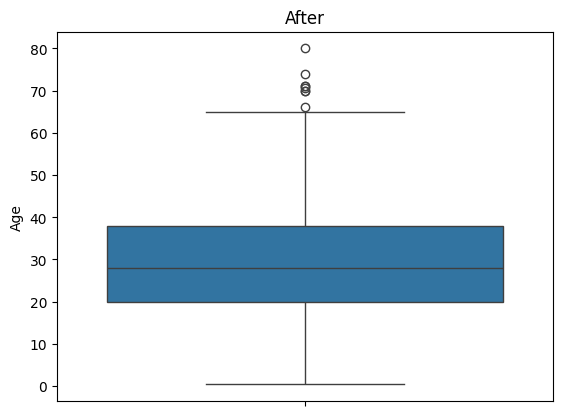

In [58]:
sns.boxplot(y=df.Age).set_title('After')

## Two passangers don't have the *Embarked* feature filled - we can drop these two rows

In [59]:
df = df.dropna()

In [60]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
PassengerId,,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,U,S
2,1,1,female,38.0,1,0,71.2833,C,C
3,1,3,female,26.0,0,0,7.9250,U,S
4,1,1,female,35.0,1,0,53.1000,C,S
5,0,3,male,35.0,0,0,8.0500,U,S
...,...,...,...,...,...,...,...,...,...
886,0,3,female,39.0,0,5,29.1250,U,Q
887,0,2,male,27.0,0,0,13.0000,U,S
888,1,1,female,19.0,0,0,30.0000,B,S


## The last step of the pre-processing pipeline is to encode *Sex*, *Cabin* and *Embarked* features 👊
* We will use one-hot encoding for *Sex* and *Embarked* and Ordinal encoding for Cabin
* Specify the encoding scheme for the ordinal encoding using an array in a form ['first', 'second', 'third', ...]

In [61]:
cabin_categories = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'U']
enc_cabin = OrdinalEncoder(categories=[cabin_categories])
enc_cabin.fit_transform(df[['Cabin']])[:, 0][:10]

array([7., 2., 7., 2., 7., 4., 7., 7., 7., 6.])

## Encode *Cabin* feature

In [62]:
df.loc[:, 'Cabin'] = enc_cabin.fit_transform(df[['Cabin']])[:, 0]

## Encode *Sex* feature

In [63]:
sex_categories = ['male', 'female']
enc_sex = OrdinalEncoder(categories=[sex_categories])
df.loc[:, 'Sex'] = enc_sex.fit_transform(df[['Sex']])[:, 0]

## Check the results

In [64]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
PassengerId,,,,,,,,,
1,0,3,0.0,22.0,1,0,7.2500,7.0,S
2,1,1,1.0,38.0,1,0,71.2833,2.0,C
3,1,3,1.0,26.0,0,0,7.9250,7.0,S
4,1,1,1.0,35.0,1,0,53.1000,2.0,S
5,0,3,0.0,35.0,0,0,8.0500,7.0,S


## The final step is to encode the *Embarked* using a one-hot encoding

In [65]:
pd.get_dummies(df['Embarked'], prefix='Embarked')

,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,
1,False,False,True
2,True,False,False
3,False,False,True
4,False,False,True
5,False,False,True
...,...,...,...
886,False,True,False
887,False,False,True
888,False,False,True


## Concat the original `df` with a `pd.get_dummies` encoding result

In [66]:
df = pd.concat([df, pd.get_dummies(df['Embarked'], prefix='Embarked')], axis=1).drop('Embarked', axis=1)

# The dataset is finally ready for the machine learning model training! 😍
* Let's take a one last look if everything is OK and we are good to go!

In [67]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,
1,0,3,0.0,22.0,1,0,7.2500,7.0,False,False,True
2,1,1,1.0,38.0,1,0,71.2833,2.0,True,False,False
3,1,3,1.0,26.0,0,0,7.9250,7.0,False,False,True
4,1,1,1.0,35.0,1,0,53.1000,2.0,False,False,True
5,0,3,0.0,35.0,0,0,8.0500,7.0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,3,1.0,39.0,0,5,29.1250,7.0,False,True,False
887,0,2,0.0,27.0,0,0,13.0000,7.0,False,False,True
888,1,1,1.0,19.0,0,0,30.0000,1.0,False,False,True


# 🚀 Let's start with splitting the data into the input and output part
* Usually named as a *X* and *y* variables
* What is the input and output?

In [68]:
X, y = df.loc[:, df.columns != 'Survived'], df.loc[:, 'Survived']

In [69]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,
1,3,0.0,22.0,1,0,7.2500,7.0,False,False,True
2,1,1.0,38.0,1,0,71.2833,2.0,True,False,False
3,3,1.0,26.0,0,0,7.9250,7.0,False,False,True
4,1,1.0,35.0,1,0,53.1000,2.0,False,False,True
5,3,0.0,35.0,0,0,8.0500,7.0,False,False,True


In [70]:
y.head()

,Survived
PassengerId,
1,0
2,1
3,1
4,1
5,0


# We usually want to split the data into two sets called `train` and `test`
* 🔎 Why do we do that?
* Note that number of rows in the *X* and *y* in the Train/Test part of the data has to be equal

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# 🌳 Create the Decision tree classifier instance

## Use `fit()` method for training the classifier

## Lets use trained model for the prediction of the survival of the passenger
* 💡 Get predictions via the `predict()` method

# How can we evaluate our model?
* There are multiple metrics used: Accuracy, Recall, Precision, F1-Score, etc.
* 💡 Very useful is also creating a confusion matrix

# 🔎 How can we select the metric?
* 💡 Accuracy and F1-Score are the most universal metrics

## 🔎 When is **Accuracy** unsuitable?

![meme02](https://github.com/rasvob/VSB-FEI-Fundamentals-of-Machine-Learning-Exercises/blob/master/images/fml_08_meme_02.jpg?raw=true)

# Take a look at this [article](https://builtin.com/data-science/precision-and-recall) and [wiki](https://en.wikipedia.org/wiki/Precision_and_recall) about precision and recall
* 💡 Beware the fact that as we increase precision, we decrease recall and vice-versa.

* **Precision** is the ratio of correctly predicted positive observations to the total predicted positive observations.
    * The question that precision answer is of all passengers that labeled as survived, how many actually survived?
    * High precision relates to the low false positive rate.


* **Recall** is the ratio of correctly predicted positive observations to the all observations in actual class - yes.
    * The question recall answers is: Of all the passengers that truly survived, how many did we label?

* **F1 Score** is the harmonic mean of Precision and Recall. Therefore, this score takes both false positives and false negatives into account.
    * Intuitively it is not as easy to understand as accuracy, but F1 is usually more useful than accuracy, especially if you have an uneven class distribution.
    * 💡 **F1 works best if false positives and false negatives have similar cost**
        * If the cost of false positives and false negatives are very different, it’s better to look at both Precision and Recall.

$ConfMatrix = \begin{bmatrix}
TP & FN\\
FP & TN
\end{bmatrix}$

## Let's take a look at an example:
$|1| = 10$

$|0| = 90$

$M = \begin{bmatrix}
1 & 9\\
0 & 90
\end{bmatrix}$

$Accuracy = \frac{TP+TN}{TP+TN+FP+FN} = \frac{1+90}{1+90+0+9} = \frac{91}{100} = 0.91$

$Precision = \frac{TP}{TP+FP} = \frac{1}{1+0} = 1$

$Recall = \frac{TP}{TP+FN} = \frac{1}{1+9} = \frac{1}{10} = 0.1$

$F1-Score = 2 \cdot \frac{Precision \cdot Recall}{Precision+Recall} = 2 \cdot \frac{1 \cdot 0.1}{1+0.1} = 2 \cdot \frac{0.1}{1.1} = 0.09$

## What does the confusion matrix tell us?
* 🔎 Where do we find true positives, false positives, etc?

In [77]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues")

NameError: name 'y_test' is not defined

In [72]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
tn, fp, fn, tp

NameError: name 'y_test' is not defined

# 🚀 We can compute any metric that we wish

# Can we improve our evaluation process?
* Lets try **cross-validation** process for the decision tree model
    * https://scikit-learn.org/stable/modules/cross_validation.html
* **What is the difference between Pure and Stratified K-Fold?**
    * 💡 Take a look at the survival ratio

## After the k-Fold CV is complete we usually want to compute statistics from the desired metric...

## ... or create a boxplot out of it 🔬

In [ ]:
skf = StratifiedKFold(n_splits=5)
scores = list()
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = DecisionTreeClassifier(random_state=13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))
    print(f'Survival ratio in train set: {y_train.value_counts(normalize=True)[1]:.2}; Survival ratio in test set: {y_test.value_counts(normalize=True)[1]:.2}')

scores

In [ ]:
np.mean(scores), np.min(scores), np.max(scores)

In [ ]:
sns.boxplot(y=scores)

# 📊 ML algorithms usually have hyper-parameters which change the behaviour of the model
* It is usually a good idea to check documentation 😊
    * https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier
* For the *DecisionTreeClassifier* a `max_depth` or `min_samples_split` are pretty important

* 🎯 The goal of the hyper-parameter tuning is to investigate the effect of the parameters on the model and ideally make the model better with setting the right parameters
    * Some models are more sensitive to parameters settings

## 🚀 Let's tune the `max_depth` first

In [ ]:
scores_global = []

scores_global[:10]

In [ ]:
df_res = pd.DataFrame.from_records(scores_global, columns=['max_depth', 'f1'])
df_res.tail()

## Now we can plot the data
* 🔎 Which setting is the best?

In [ ]:
sns.lineplot(data = df_res, x='max_depth', y='f1')

In [ ]:
df_res.sort_values(by='f1', ascending=False).head(5)

## 🚀 Now we can continue with `min_samples_split`

In [ ]:
scores_global = []
for x in np.arange(2, 50):
    skf = KFold(n_splits=5)
    scores = []
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        clf = DecisionTreeClassifier(min_samples_split = x, random_state = 13)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        scores.append(f1_score(y_test, y_pred))
    scores_global.append((x, np.mean(scores)))

scores_global[:10]

In [ ]:
df_res = pd.DataFrame.from_records(scores_global, columns=['min_samples_split', 'f1'])
df_res.tail(10)

In [ ]:
sns.lineplot(data = df_res, x='min_samples_split', y='f1')

### Which setting is the best?

In [ ]:
df_res.sort_values(by='f1', ascending=False).head(5)

## 🎯 So now we can try the combination of the best parameter-wise settings

In [ ]:
skf = KFold(n_splits=5)
scores = []
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = DecisionTreeClassifier(max_depth = 8, min_samples_split = 12, random_state = 13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

np.mean(scores), np.min(scores), np.max(scores)

### 🔎 Is the model now better than the *default* one?

## Alternatively we can tune both parameters at once 😇

In [ ]:
scores_global = []
for d in range(2, 25):
    for split in range(2, 50):
        skf = KFold(n_splits=5)
        scores = []
        for train_index, test_index in skf.split(X, y):
            X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
            y_train, y_test = y.iloc[train_index], y.iloc[test_index]
            clf = DecisionTreeClassifier(max_depth = d, min_samples_split = split, random_state = 13)
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            scores.append(f1_score(y_test, y_pred))
        scores_global.append((d, split, np.mean(scores)))

In [ ]:
df_res = pd.DataFrame.from_records(scores_global, columns=['max_depth', 'min_samples_split', 'f1'])
df_res.sort_values(by='f1', ascending=False).head(5)

## And try the best combination again 😊
* 💡You don't have to write these codes by hand, sklearn already provides function for it
    * https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html#sklearn.model_selection.GridSearchCV
    * https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html#sklearn.model_selection.RandomizedSearchCV

In [ ]:
skf = KFold(n_splits=5)
scores = []
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    clf = DecisionTreeClassifier(max_depth = 6, min_samples_split = 11, random_state = 13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores.append(f1_score(y_test, y_pred))

np.mean(scores), np.min(scores), np.max(scores)

# ✅ Task (2p)
* Take a look at the different models in the sklearn
    * https://scikit-learn.org/stable/supervised_learning.html
* Choose one model that you want to try, check how it works and what hyperparameters are the most important
    * You know some of them from the the lectures but you can also check online tutorials, blogs or YouTube 🙂
* Use the model in default settings
* Tune at least one of the hyper-parameters and compare the model proposed during the lecture and the one you just created
    * Beat the default `DecisionTreeClassifier`

* **Describe the insight you got from the experiments with a few sentences in a Markdown cell**
    * Mention what parameters you tuned and if the hyperparameter tuning helped!
    * ❌ Results interpretation figured in real-time during task check is not allowed! ❌

![meme03](https://github.com/rasvob/VSB-FEI-Fundamentals-of-Machine-Learning-Exercises/blob/master/images/fml_08_meme_03.jpg?raw=true)

In [78]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import numpy as np


In [83]:
skf = KFold(n_splits=5, shuffle=True, random_state=13)

scores_hgb_default = []
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    clf = HistGradientBoostingClassifier(random_state=13)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    scores_hgb_default.append(f1_score(y_test, y_pred))

print("HGB (default) F1 -> mean/min/max:",
      np.mean(scores_hgb_default).round(4),
      np.min(scores_hgb_default).round(4),
      np.max(scores_hgb_default).round(4))


HGB (default) F1 -> mean/min/max: 0.7377 0.7129 0.7874


In [82]:
splits

[(array([  1,   2,   5,   6,   7,   8,   9,  11,  12,  13,  14,  15,  16,
          17,  19,  20,  22,  23,  24,  25,  26,  27,  28,  30,  31,  32,
          34,  35,  36,  38,  39,  41,  42,  43,  45,  46,  47,  48,  49,
          50,  53,  54,  55,  56,  57,  59,  60,  61,  62,  63,  64,  66,
          67,  68,  69,  70,  71,  72,  73,  74,  75,  78,  79,  80,  81,
          82,  83,  84,  86,  88,  89,  90,  91,  92,  93,  95,  96, 100,
         102, 103, 104, 107, 109, 110, 113, 116, 117, 118, 119, 120, 121,
         122, 123, 124, 125, 126, 128, 129, 130, 131, 132, 134, 137, 138,
         139, 141, 142, 143, 145, 146, 147, 148, 149, 151, 152, 153, 154,
         155, 158, 160, 161, 162, 163, 164, 165, 166, 167, 169, 170, 171,
         172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184,
         185, 186, 187, 188, 189, 190, 191, 193, 194, 195, 196, 197, 199,
         200, 201, 202, 203, 204, 205, 207, 209, 211, 212, 213, 214, 217,
         218, 219, 221, 223, 224, 225,

In [81]:
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    "learning_rate": [0.05, 0.1, 0.2],
    "max_leaf_nodes": [15, 31, 63],
    "max_iter": [100, 200, 400],
    "l2_regularization": [0.0, 1e-3, 1e-2],
}

best = {"score": -1, "params": None}

scores_dt = []

skf = KFold(n_splits=5, shuffle=True, random_state=13)
splits = list(skf.split(X, y))  # freeze splits to compare models fairly

for train_index, test_index in splits:
    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    dt = DecisionTreeClassifier(random_state=13)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    scores_dt.append(f1_score(y_test, y_pred))

scores_hgb_tuned_all = []
for lr in param_grid["learning_rate"]:
    for mln in param_grid["max_leaf_nodes"]:
        for it in param_grid["max_iter"]:
            for l2 in param_grid["l2_regularization"]:
                fold_scores = []
                for train_index, test_index in splits:
                    X_train, X_test = X.iloc[train_index, :], X.iloc[test_index, :]
                    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

                    clf = HistGradientBoostingClassifier(
                        learning_rate=lr,
                        max_leaf_nodes=mln,
                        max_iter=it,
                        l2_regularization=l2,
                        random_state=13,
                        early_stopping=True
                    )
                    clf.fit(X_train, y_train)
                    y_pred = clf.predict(X_test)
                    fold_scores.append(f1_score(y_test, y_pred))

                mean_f1 = float(np.mean(fold_scores))
                scores_hgb_tuned_all.append(
                    {"params": {"learning_rate": lr, "max_leaf_nodes": mln, "max_iter": it, "l2_regularization": l2},
                     "scores": fold_scores,
                     "mean_f1": mean_f1}
                )
                if mean_f1 > best["score"]:
                    best["score"] = mean_f1
                    best["params"] = {"learning_rate": lr, "max_leaf_nodes": mln, "max_iter": it, "l2_regularization": l2}

print("DecisionTree (default) F1 -> mean/min/max:",
      np.mean(scores_dt).round(4),
      np.min(scores_dt).round(4),
      np.max(scores_dt).round(4))

print("HGB (tuned best) params:", best["params"])
print("HGB (tuned best) mean F1:", round(best["score"], 4))

if 'scores_hgb_default' in globals():
    print("HGB (default) mean F1:", round(np.mean(scores_hgb_default), 4))


DecisionTree (default) F1 -> mean/min/max: 0.6825 0.65 0.6942
HGB (tuned best) params: {'learning_rate': 0.05, 'max_leaf_nodes': 15, 'max_iter': 100, 'l2_regularization': 0.0}
HGB (tuned best) mean F1: 0.757
HGB (default) mean F1: 0.7377
